In [1]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

In [11]:
pip uninstall d2l -y

Found existing installation: d2l 1.0.3Note: you may need to restart the kernel to use updated packages.

Uninstalling d2l-1.0.3:
  Successfully uninstalled d2l-1.0.3


In [12]:
pip install d2l==0.17.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
max_degree = 20  # 多项式的最大阶数
n_train, n_test = 100, 100  # 训练和测试数据集大小
true_w = np.zeros(max_degree)  # 分配大量的空间，真实权重（仅前4项非零，对应3次多项式）
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)   # 打乱样本顺序
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))  # 生成x^0到x^19的高次项
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # 除以i!（gamma(n)=(n-1)!）
# labels的维度:(n_train+n_test,)
labels = np.dot(poly_features, true_w)  # 多项式计算（无噪声标签）
labels += np.random.normal(scale=0.1, size=labels.shape)  # 加入高斯噪声（模拟真实数据的观测误差）

In [3]:
true_w, features, poly_features, labels = [torch.tensor(x, dtype=torch.float32) for x in [true_w, features, poly_features, labels]]

In [4]:
features[:2], poly_features[:2, :], labels[:2]

(tensor([[1.2477],
         [1.7305]]),
 tensor([[1.0000e+00, 1.2477e+00, 7.7840e-01, 3.2374e-01, 1.0098e-01, 2.5200e-02,
          5.2404e-03, 9.3408e-04, 1.4568e-04, 2.0197e-05, 2.5200e-06, 2.8584e-07,
          2.9721e-08, 2.8526e-09, 2.5423e-10, 2.1147e-11, 1.6491e-12, 1.2104e-13,
          8.3900e-15, 5.5096e-16],
         [1.0000e+00, 1.7305e+00, 1.4974e+00, 8.6376e-01, 3.7369e-01, 1.2934e-01,
          3.7304e-02, 9.2222e-03, 1.9949e-03, 3.8359e-04, 6.6381e-05, 1.0443e-05,
          1.5060e-06, 2.0048e-07, 2.4781e-08, 2.8590e-09, 3.0923e-10, 3.1478e-11,
          3.0263e-12, 2.7564e-13]]),
 tensor([5.5065, 6.8954]))

In [5]:
def evaluate_loss(net, data_iter, loss):  #@save
    metric = d2l.Accumulator(2)  
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [9]:
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),
                                batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

RuntimeError: grad can be implicitly created only for scalar outputs

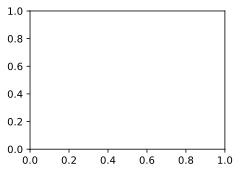

In [10]:
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

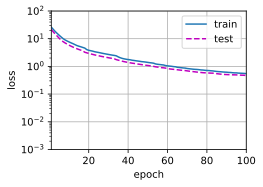

In [18]:
import torch
from torch import nn
import math
from d2l import torch as d2l

# -------------------------- 1. 每次训练重新生成迭代器（避免耗尽）--------------------------
def get_data_iter(batch_size, features, labels):
    """每次调用生成新的迭代器，避免耗尽"""
    num_examples = len(features)
    indices = list(range(num_examples))
    np.random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

# -------------------------- 2. 生成数据集（不变）--------------------------
max_degree = 20
n_train, n_test = 100, 100
true_w = np.zeros(max_degree)
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)

labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)
true_w, features, poly_features, labels = [
    torch.tensor(x, dtype=torch.float32) for x in [true_w, features, poly_features, labels]
]
labels = labels.reshape(-1, 1)

# -------------------------- 3. 模型与损失函数（不变）--------------------------
net = nn.Sequential(nn.Linear(4, 1))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
        nn.init.zeros_(m.bias)
net.apply(init_weights)

loss = nn.MSELoss()
trainer = torch.optim.SGD(net.parameters(), lr=0.01)

# -------------------------- 4. 手动评估损失（不变）--------------------------
def evaluate_loss(net, data_iter, loss):
    net.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += l.item() * y.shape[0]
            total_samples += y.shape[0]
    net.train()
    return total_loss / total_samples if total_samples > 0 else 0.0

# -------------------------- 5. 修复训练循环（确保迭代器与可视化正常）--------------------------
def train(train_features, test_features, train_labels, test_labels, num_epochs=100):
    batch_size = 32
    # 初始化可视化（强制设置y轴范围，避免小损失被压缩）
    try:
        animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                                xlim=[1, num_epochs], ylim=[1e-3, 1e2],  # 调整y轴范围，覆盖损失值
                                legend=['train', 'test'])
    except AttributeError:
        animator = None
        print("d2l.Animator不可用，将打印损失值")

    for epoch in range(num_epochs):
        # 关键：每次训练重新生成迭代器（避免耗尽）
        train_iter = get_data_iter(batch_size, train_features, train_labels)
        test_iter = get_data_iter(batch_size, test_features, test_labels)

        # 手动训练单轮
        net.train()
        train_loss_sum = 0.0
        train_samples = 0
        for X, y in train_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            trainer.zero_grad()
            l.backward()
            trainer.step()
            train_loss_sum += l.item() * y.shape[0]
            train_samples += y.shape[0]

        # 计算损失
        train_loss = train_loss_sum / train_samples if train_samples > 0 else 0.0
        test_loss = evaluate_loss(net, test_iter, loss)

        # 每轮强制更新可视化（避免累积延迟）
        if animator:
            animator.add(epoch + 1, (train_loss, test_loss))
        else:
            if epoch % 10 == 0:
                print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

# -------------------------- 6. 启动训练 --------------------------
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:], num_epochs=100)

In [22]:
import torch
from torch import nn
import math
from d2l import torch as d2l

# -------------------------- 1. 每次训练重新生成迭代器（避免耗尽）--------------------------
def get_data_iter(batch_size, features, labels):
    """每次调用生成新的迭代器，避免耗尽"""
    num_examples = len(features)
    indices = list(range(num_examples))
    np.random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

# -------------------------- 2. 生成数据集（不变）--------------------------
max_degree = 20
n_train, n_test = 100, 100
true_w = np.zeros(max_degree)
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)

labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)
true_w, features, poly_features, labels = [
    torch.tensor(x, dtype=torch.float32) for x in [true_w, features, poly_features, labels]
]
labels = labels.reshape(-1, 1)

# -------------------------- 3. 模型与损失函数（不变）--------------------------
net = nn.Sequential(nn.Linear(2, 2))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
        nn.init.zeros_(m.bias)
net.apply(init_weights)

loss = nn.MSELoss()
trainer = torch.optim.SGD(net.parameters(), lr=0.01)

# -------------------------- 4. 手动评估损失（不变）--------------------------
def evaluate_loss(net, data_iter, loss):
    net.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += l.item() * y.shape[0]
            total_samples += y.shape[0]
    net.train()
    return total_loss / total_samples if total_samples > 0 else 0.0

# -------------------------- 5. 修复训练循环（确保迭代器与可视化正常）--------------------------
def train(train_features, test_features, train_labels, test_labels, num_epochs=100):
    batch_size = 32
    # 初始化可视化（强制设置y轴范围，避免小损失被压缩）
    try:
        animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                                xlim=[1, num_epochs], ylim=[1e-3, 1e2],  # 调整y轴范围，覆盖损失值
                                legend=['train', 'test'])
    except AttributeError:
        animator = None
        print("d2l.Animator不可用，将打印损失值")

    for epoch in range(num_epochs):
        # 关键：每次训练重新生成迭代器（避免耗尽）
        train_iter = get_data_iter(batch_size, train_features, train_labels)
        test_iter = get_data_iter(batch_size, test_features, test_labels)

        # 手动训练单轮
        net.train()
        train_loss_sum = 0.0
        train_samples = 0
        for X, y in train_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            trainer.zero_grad()
            l.backward()
            trainer.step()
            train_loss_sum += l.item() * y.shape[0]
            train_samples += y.shape[0]

        # 计算损失
        train_loss = train_loss_sum / train_samples if train_samples > 0 else 0.0
        test_loss = evaluate_loss(net, test_iter, loss)

        # 每轮强制更新可视化（避免累积延迟）
        if animator:
            animator.add(epoch + 1, (train_loss, test_loss))
        else:
            if epoch % 10 == 0:
                print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")


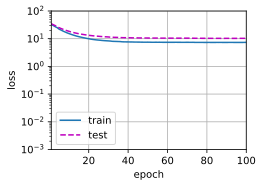

In [23]:
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

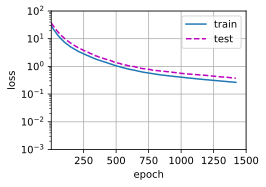

In [ ]:
import torch
from torch import nn
import math
from d2l import torch as d2l

# -------------------------- 1. 每次训练重新生成迭代器（避免耗尽）--------------------------
def get_data_iter(batch_size, features, labels):
    """每次调用生成新的迭代器，避免耗尽"""
    num_examples = len(features)
    indices = list(range(num_examples))
    np.random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

# -------------------------- 2. 生成数据集（不变）--------------------------
max_degree = 20
n_train, n_test = 100, 100
true_w = np.zeros(max_degree)
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)

labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)
true_w, features, poly_features, labels = [
    torch.tensor(x, dtype=torch.float32) for x in [true_w, features, poly_features, labels]
]
labels = labels.reshape(-1, 1)

# -------------------------- 3. 模型与损失函数（不变）--------------------------
net = nn.Sequential(nn.Linear(20, 10))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
        nn.init.zeros_(m.bias)
net.apply(init_weights)

loss = nn.MSELoss()
trainer = torch.optim.SGD(net.parameters(), lr=0.01)

# -------------------------- 4. 手动评估损失（不变）--------------------------
def evaluate_loss(net, data_iter, loss):
    net.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += l.item() * y.shape[0]
            total_samples += y.shape[0]
    net.train()
    return total_loss / total_samples if total_samples > 0 else 0.0

# -------------------------- 5. 修复训练循环（确保迭代器与可视化正常）--------------------------
def train(train_features, test_features, train_labels, test_labels, num_epochs=100):
    batch_size = 32
    # 初始化可视化（强制设置y轴范围，避免小损失被压缩）
    try:
        animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                                xlim=[1, num_epochs], ylim=[1e-3, 1e2],  # 调整y轴范围，覆盖损失值
                                legend=['train', 'test'])
    except AttributeError:
        animator = None
        print("d2l.Animator不可用，将打印损失值")

    for epoch in range(num_epochs):
        # 关键：每次训练重新生成迭代器（避免耗尽）
        train_iter = get_data_iter(batch_size, train_features, train_labels)
        test_iter = get_data_iter(batch_size, test_features, test_labels)

        # 手动训练单轮
        net.train()
        train_loss_sum = 0.0
        train_samples = 0
        for X, y in train_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            trainer.zero_grad()
            l.backward()
            trainer.step()
            train_loss_sum += l.item() * y.shape[0]
            train_samples += y.shape[0]

        # 计算损失
        train_loss = train_loss_sum / train_samples if train_samples > 0 else 0.0
        test_loss = evaluate_loss(net, test_iter, loss)

        # 每轮强制更新可视化（避免累积延迟）
        if animator:
            animator.add(epoch + 1, (train_loss, test_loss))
        else:
            if epoch % 10 == 0:
                print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=1500)

# 总结：模型选择、欠拟合与过拟合

## 一、核心目标与关键误差

### 1. 机器学习的核心目标

发现**泛化性模式**：模型能对从未见过的新数据做出准确预测，而非仅“死记硬背”训练数据（单纯记忆无实际部署价值）。

### 2. 两大关键误差对比

|误差类型|定义|特点|
|---|---|---|
|训练误差|模型在训练数据集上计算得到的误差|可直接计算，反映模型对训练数据的拟合程度|
|泛化误差|模型对“从原始数据分布中抽取的无限多新样本”的误差期望|无法直接计算，需通过独立测试集/验证集估计，是衡量模型实用价值的核心指标|
### 3. 基础假设：独立同分布（i.i.d.）

- **假设内容**：训练数据和测试数据均从同一分布中独立抽取（即样本间无关联，分布一致）；

- **现实意义**：多数机器学习算法的理论基础，若违背（如用“大学生人脸数据”训练、“老年人数据”测试），模型泛化能力会大幅下降；

- **灵活边界**：轻微违背时（如不同地区的相似用户数据）模型可能仍有效，但严重违背（数据分布差异过大）会导致失效。

## 二、欠拟合与过拟合的核心区别

### 1. 定义与特征对比

|现象|定义|关键特征（训练误差 vs 验证误差）|本质原因|
|---|---|---|---|
|欠拟合|模型过于简单，无法捕捉数据中的潜在规律（如用线性模型拟合非线性数据）|训练误差和验证误差均**显著偏高**，且两者差距极小|模型表达能力不足（复杂度不够）|
|过拟合|模型过于复杂，拟合了训练数据中的噪声而非核心规律|训练误差**极低**，但验证误差**显著偏高**，两者差距大|模型复杂度超出数据需求，记忆噪声|
### 2. 关键补充说明

- 过拟合≠“训练误差低”：深度学习中优秀模型的训练误差常低于验证误差，但需控制差距（过度过拟合会导致模型完全无法泛化）；

- 过拟合极端案例：用“与样本数量相等阶数的多项式”拟合数据，可实现训练误差为0，但对新样本预测误差极大（仅记忆训练数据）。

## 三、模型复杂性的影响因素

模型复杂性决定拟合能力，直接影响欠拟合/过拟合风险，核心影响因素包括：

1. **可调整参数数量（自由度）**  

    - 参数越多，模型越灵活（如20阶多项式 vs 2阶多项式），越易过拟合；

    - 例：多层感知机中“隐藏层数量/隐藏单元数”越多，模型复杂度越高。

2. **参数取值范围**  

    - 权重取值范围越大（如无约束的线性层权重），模型可能越复杂，易过拟合。

3. **训练迭代次数**  

    - 训练轮次越多，模型越可能“过度挖掘”训练数据中的噪声，需通过“早停（early stopping）”控制复杂度。

4. **模型类型差异**  

    - 不同大类模型（如决策树 vs 神经网络）的复杂性难以直接比较，需结合具体数据场景评估（如简单表格数据用决策树更合适，复杂图像数据需神经网络）。

### 核心逻辑公式

- 简单模型 + 大量数据 → 泛化误差 ≈ 训练误差，不易过拟合；

- 复杂模型 + 少量数据 → 训练误差低但泛化误差高，极易过拟合。

## 四、模型选择的常用方法

模型选择的核心目标：避免“过拟合测试集”，需通过专门数据验证，常用两种方法：

### 1. 验证集划分法

#### （1）数据拆分逻辑

将原始数据分为三类，各司其职：

- **训练集**：用于模型参数训练（占比通常60%-80%）；

- **验证集**：用于模型选择、超参数调优（如选择多项式阶数、学习率，占比10%-20%）；

- **测试集**：仅用于最终泛化能力评估（占比10%-20%）。

#### （2）关键原则

- 测试集“一次性使用”：仅在所有模型/超参数确定后，用于最终评估，不可参与任何模型调优（避免过拟合测试集）；

- 现实简化：多数实验中（如教材案例）会简化为“训练集+验证集”，报告的“测试误差”实际为验证误差。

### 2. K折交叉验证法

#### （1）适用场景

训练数据稀缺（如医疗数据），无法划分出足够大的独立验证集。

#### （2）核心步骤

1. 将原始训练数据均匀划分为**K个不重叠子集**（常用K=5或K=10）；

2. 循环K次训练与验证：

    - 第i次（i=1到K）：用“前K-1个子集”训练模型，用“第i个子集”作为验证集计算误差；

3. 最终结果：取K次验证误差的**平均值**作为模型泛化能力的估计（降低随机划分带来的误差）。

## 五、数据集大小的核心影响

1. **数据量与过拟合风险**：数据量越少，过拟合风险越高（少量数据易被复杂模型“记满”噪声）；

2. **数据量与泛化误差**：数据量越多，泛化误差通常越低（更多数据能“约束”模型，凸显核心规律）；

3. **数据与模型的匹配度**：更多数据可支撑更复杂的模型（如深度学习需“数千+样本”才能优于线性模型，而线性模型用“数百样本”即可起效）。

## 六、实验验证：多项式回归案例

以“三阶多项式生成真实数据（含噪声）”为基础，验证不同模型的拟合效果：

|模型类型|特征选择（多项式阶数相关）|拟合效果描述|对应现象|
|---|---|---|---|
|三阶多项式|前4维特征（1, x, x²/2!, x³/3!）|训练误差、验证误差均低，权重接近真实值（[5,1.2,-3.4,5.6]）|正常拟合|
|线性模型|前2维特征（1, x）|训练误差、验证误差均显著偏高|欠拟合（表达不足）|
|二十阶多项式|全部20维特征（1到x¹⁹/19!）|训练误差极低，但验证误差显著偏高|过拟合（复杂度超标）|
## 七、核心小结

1. 泛化能力是模型的核心价值，**训练误差≠泛化误差**，不可仅通过训练误差判断模型好坏；

2. 欠拟合的本质是“模型太简单”，过拟合的本质是“模型太复杂”；

3. 模型选择需依赖验证集/K折交叉验证，**测试集不可参与调优**；

4. 优化方向：匹配“模型复杂度”与“数据量”（简单数据用简单模型，复杂数据需足够样本支撑复杂模型）；

5. 后续解决方案：通过“权重衰减、dropout、早停”等正则化技术缓解过拟合。